In [31]:
from POSEIDON.core import create_star
from POSEIDON.core import  create_planet
from POSEIDON.constants import R_Sun, R_E, M_E
import numpy as np



#***** Define stellar properties *****#

R_s =  0.1192 * R_Sun    # Stellar radius (m)
T_s = 2566.0          # Stellar effective temperature (K)
Met_s = 0.00         # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 5.2396

# Create the stellar object



star = create_star(R_s, T_s, log_g_s, Met_s,
                   stellar_grid= "phoenix",
                   stellar_contam="two_spots",
                   f_spot=0.01, T_spot=0.86 * T_s,
                   f_fac=0.08, T_fac=T_s + 100,
                   )


                   #***** Define planet properties *****#

planet_name = 'Trappist-1e'
R_p = 0.917985*R_E     # Planetary radius (m)
M_p = 0.6356*M_E       # Planetary mass (kg)
T_eq = 255.0           # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

AttributeError: 'Legend' object has no attribute 'legend_handles'

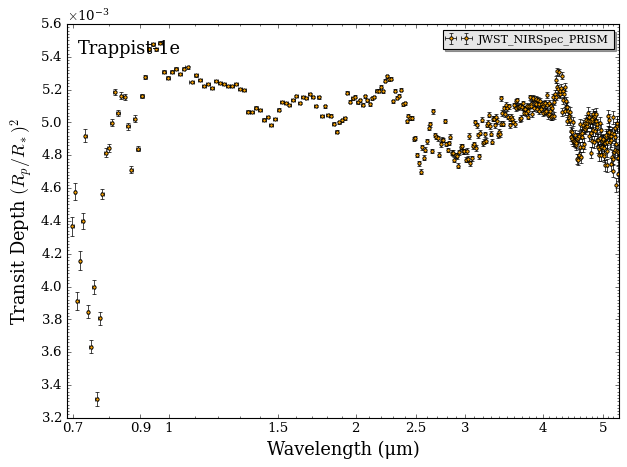

In [ ]:
from POSEIDON.core import load_data, wl_grid_constant_R
from POSEIDON.visuals import plot_data


# 


observation = 'pandexo_output_100transits_fspot0.26_ffac0.70.dat'
#***** Model wavelength grid *****#

wl_min = 0.4      # Minimum wavelength (um)
wl_max = 6.0      # Maximum wavelength (um)
R = 4000         # Spectral resolution of grid

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Specify data location and instruments  *****#

data_dir = 'observations'         # Change this to where your data is stored
datasets = [observation]  # Found in reference_data/observations
instruments = ['JWST_NIRSpec_PRISM']             # Instruments corresponding to the data

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)


# Plot our data
fig_data = plot_data(data, planet_name)

In [ ]:
from POSEIDON.core import define_model

#***** Define model *****#
model_name = 'contam_100T_0.26spot-0.70fac'  # Model name used for plots, output files etc.

bulk_species = ['N2']      # H2 + He comprises the bulk atmosphere
param_species = ['H2O', 'CH4', 'CO2', "O3"]   # The trace gases are H2O and CH4

# Create the model object
model = define_model(model_name, bulk_species, param_species,
                     PT_profile = 'isotherm', cloud_model = 'cloud-free',
                     stellar_contam = "two_spots"
                     )

# Check the free parameters defining this model
print("Free parameters: " + str(model['param_names']))

Free parameters: ['R_p_ref' 'T' 'log_H2O' 'log_CH4' 'log_CO2' 'log_O3' 'f_spot' 'f_fac'
 'T_spot' 'T_fac' 'T_phot']


In [ ]:
from POSEIDON.core import set_priors

#***** Set priors for retrieval *****#

# Initialise prior type dictionary
prior_types = {}

# Specify whether priors are linear, Gaussian, etc.
prior_types['T'] = 'uniform'
prior_types['R_p_ref'] = 'uniform'
prior_types['log_H2O'] = 'uniform'
#'log_H2O' 'log_CH4' 'log_CO2' 'log_O3'
prior_types['log_CH4'] = 'uniform'
prior_types['log_CO2'] = 'uniform'
prior_types['log_O3'] = 'uniform'
prior_types["f_spot"] = 'uniform'
prior_types["f_fac"] = 'uniform'
prior_types["T_phot"] = "uniform"
prior_types["T_fac"] = "uniform"
prior_types["T_spot"] = "uniform"


# Initialise prior range dictionary
prior_ranges = {}

# Specify prior ranges for each free parameter
prior_ranges['T'] = [200, 400]
prior_ranges['R_p_ref'] = [0.85*R_p, 1.15*R_p]
prior_ranges['log_H2O'] = [-8, -1]
prior_ranges['log_CH4'] = [-8, -1]
prior_ranges['log_CO2'] = [-5, -1]
prior_ranges['log_O3'] = [-8, -1]
prior_ranges["f_spot"] = [0, 0.26]
prior_ranges["f_fac"] = [0, 0.7]
prior_ranges["T_phot"] = [0.9*T_s, 1.1*T_s]
prior_ranges["T_fac"] = [T_s, T_s+15]
prior_ranges["T_spot"] = [0.8*T_s, 0.9*T_s]

# Create prior object for retrieval
priors = set_priors(planet, star, model, data, prior_types, prior_ranges)

In [ ]:
from POSEIDON.core import read_opacities
import numpy as np

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 200     # Same as prior range for T
T_fine_max = 400    # Same as prior range for T
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -2   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Pre-interpolate the opacities
opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
H2O done
CH4 done
CO2 done
O3 done
Opacity pre-interpolation complete.


In [ ]:
""" from POSEIDON.stellar import precompute_stellar_spectra


precompute_stellar_spectra(
    comm = 1,
    wl_out = wl,
    star = star, 
    prior_types = prior_types,
    prior_ranges = prior_ranges,
    stellar_contam = "two_spots",
    T_step_interp = 20,
) """

' from POSEIDON.stellar import precompute_stellar_spectra\n\n\nprecompute_stellar_spectra(\n    comm = 1,\n    wl_out = wl,\n    star = star, \n    prior_types = prior_types,\n    prior_ranges = prior_ranges,\n    stellar_contam = "two_spots",\n    T_step_interp = 20,\n) '

In [ ]:
""" from POSEIDON.retrieval import run_retrieval

#***** Specify fixed atmospheric settings for retrieval *****#

# Atmospheric pressure grid
P_min = 1.0e-2    # 0.1 bar
P_max = 2       # 2 bar
N_layers = 100    # 100 layers

# Let's space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure
P_ref = 1.0   # Retrieved R_p_ref parameter will be the radius at 1 bar

#***** Run atmospheric retrieval *****#

run_retrieval(planet, star, model, opac, data, priors, wl, P, P_ref, R = R,
              spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',
              N_live = 50, verbose = True) """

" from POSEIDON.retrieval import run_retrieval\n\n#***** Specify fixed atmospheric settings for retrieval *****#\n\n# Atmospheric pressure grid\nP_min = 1.0e-2    # 0.1 bar\nP_max = 2       # 2 bar\nN_layers = 100    # 100 layers\n\n# Let's space the layers uniformly in log-pressure\nP = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)\n\n# Specify the reference pressure\nP_ref = 1.0   # Retrieved R_p_ref parameter will be the radius at 1 bar\n\n#***** Run atmospheric retrieval *****#\n\nrun_retrieval(planet, star, model, opac, data, priors, wl, P, P_ref, R = R,\n              spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',\n              N_live = 50, verbose = True) "

Generating corner plot ...


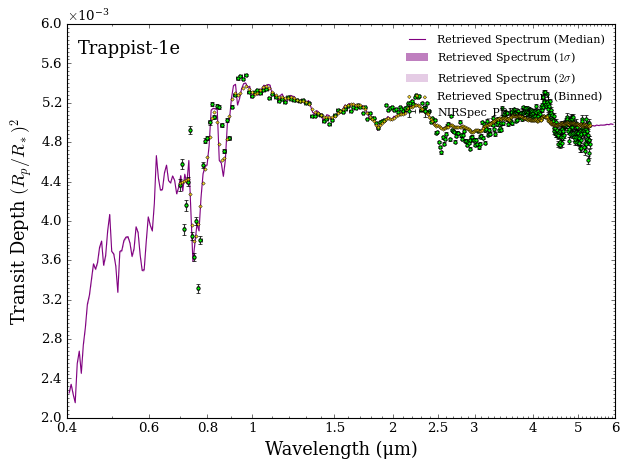

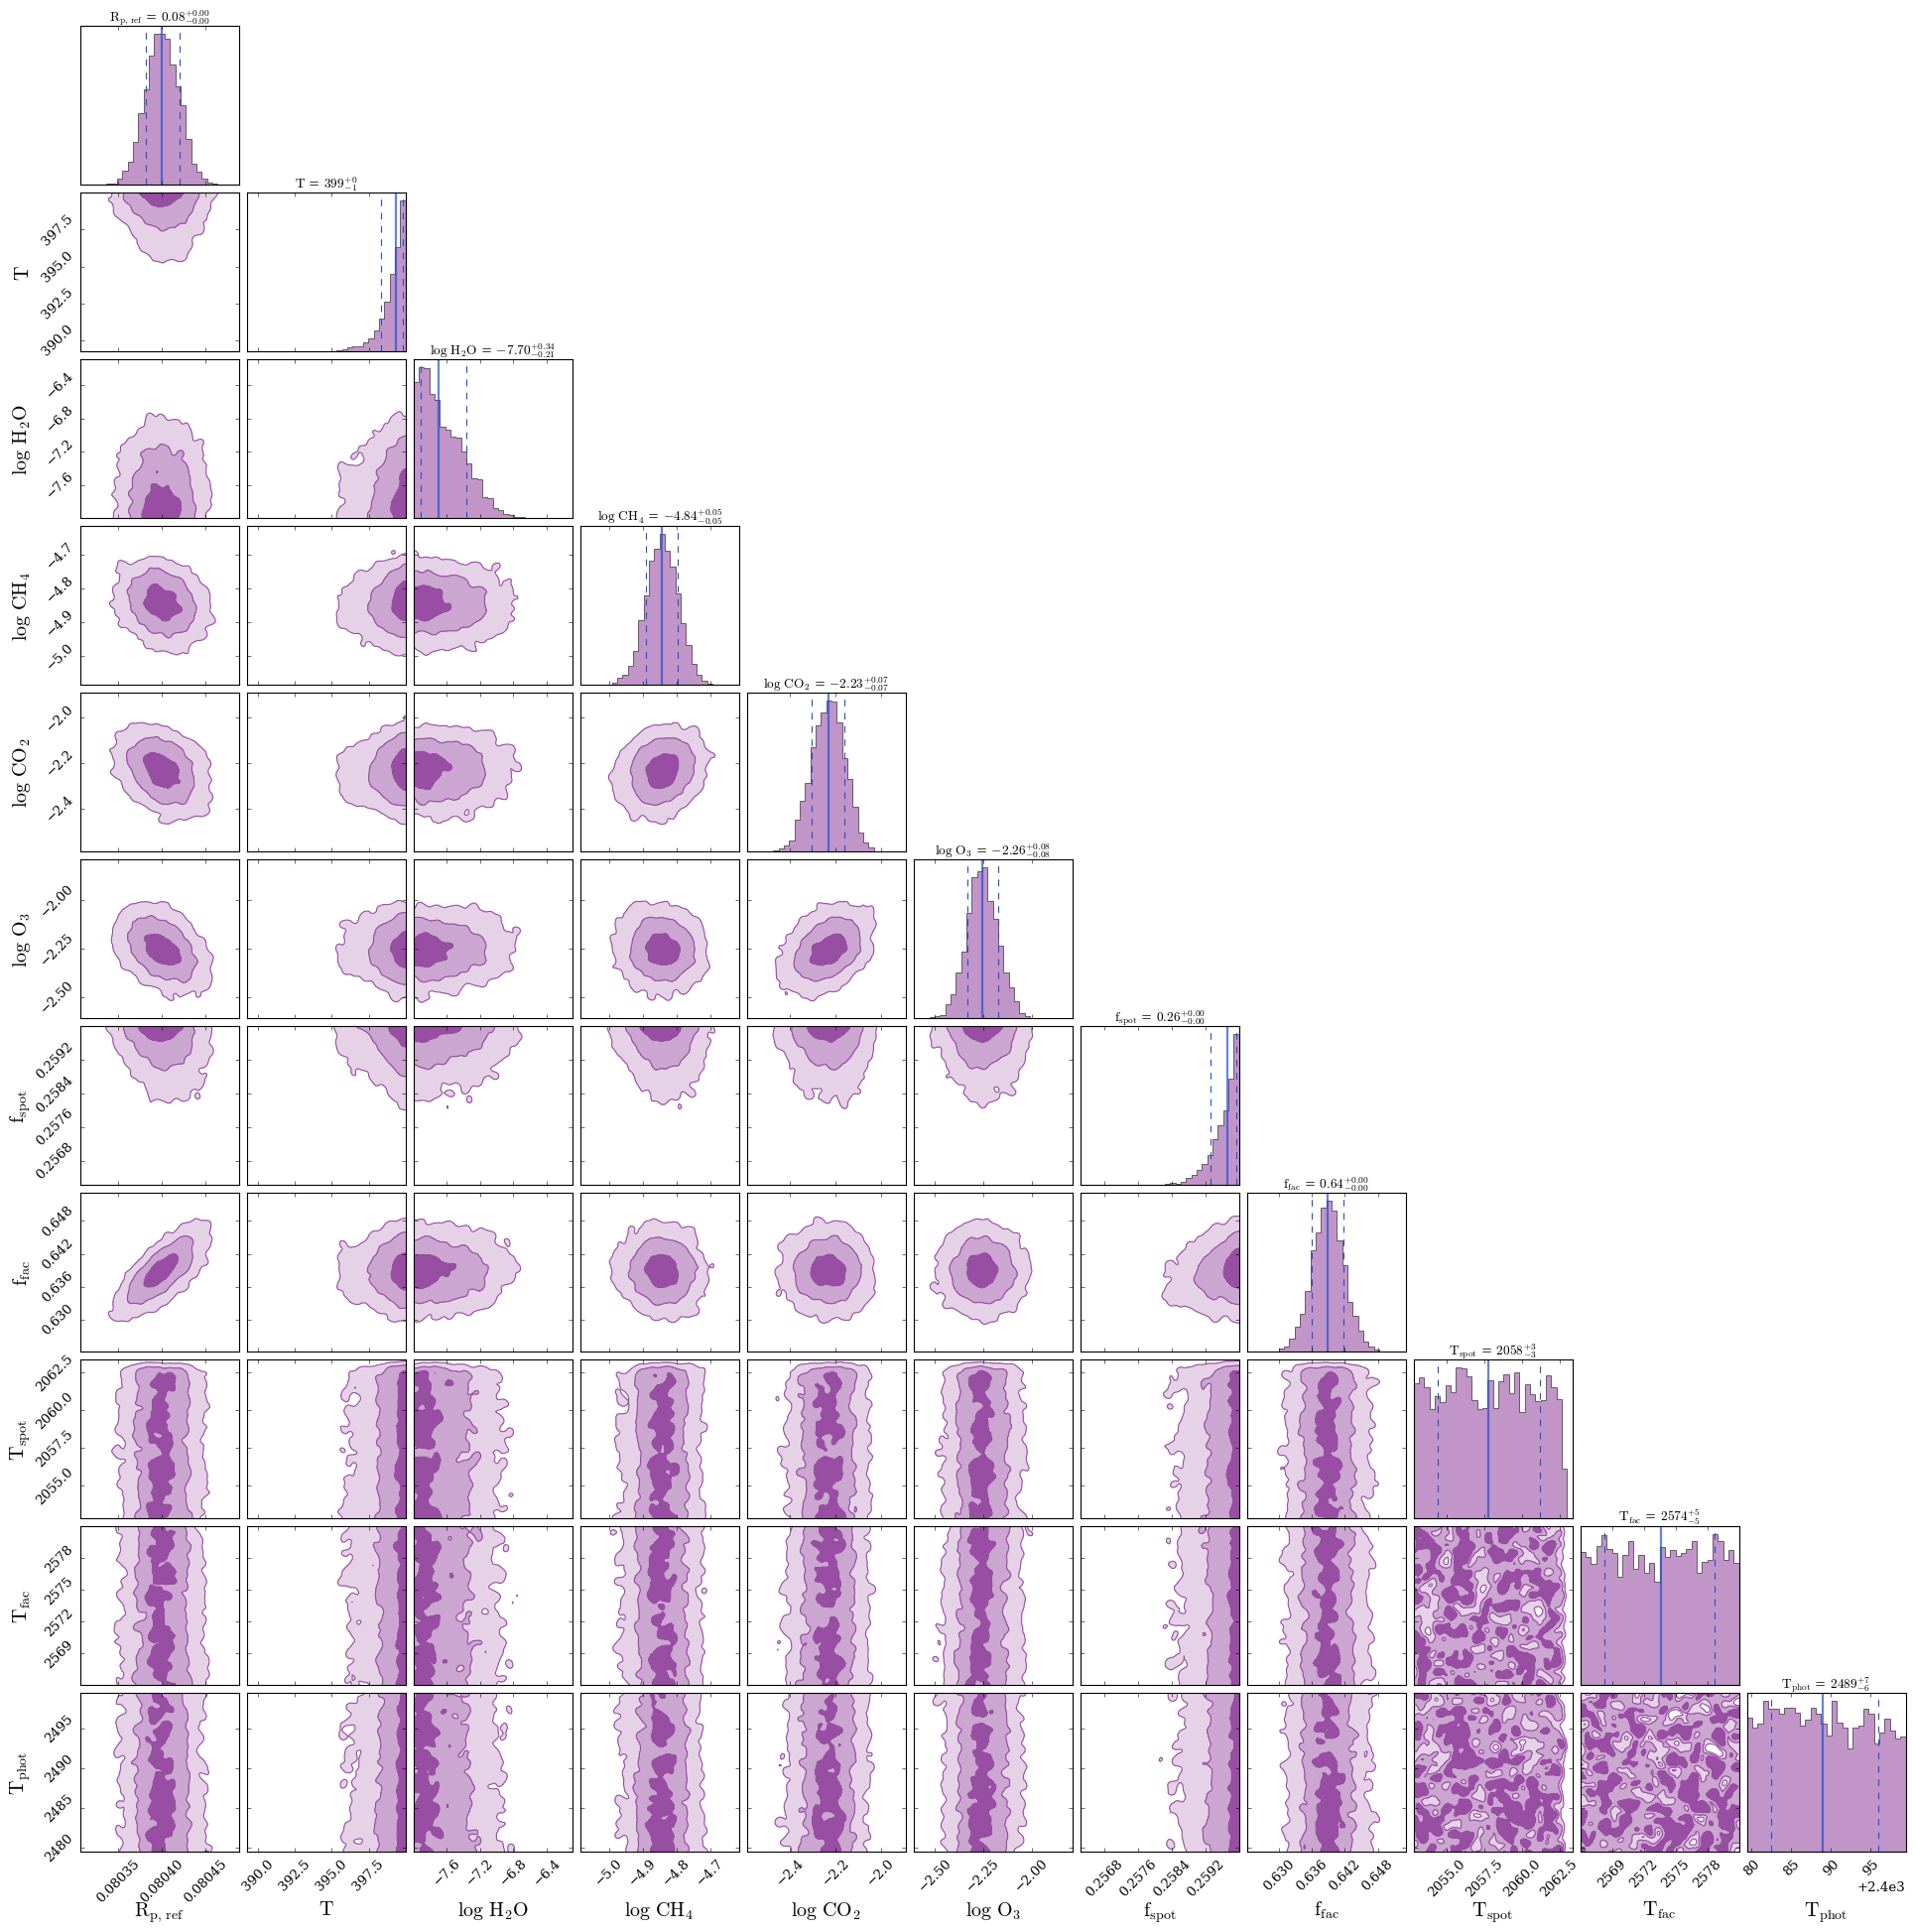

In [ ]:
from POSEIDON.utility import read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_spectra_retrieved
from POSEIDON.corner import generate_cornerplot

#***** Plot retrieved transmission spectrum *****#

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Produce figure
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1,
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100,
                                  data_labels = ['NIRSpec_PRISM'],
                                  data_colour_list = ['lime'])

#***** Make corner plot *****#

fig_corner = generate_cornerplot(planet, model)

True_flux = spec_median

In [24]:
from POSEIDON.stellar import stellar_contamination

star = create_star(R_s, 2489, log_g_s, Met_s,
                   stellar_grid= "phoenix",
                   stellar_contam="two_spots",
                   f_spot=0.26, T_spot=2058,
                   f_fac=0.64, T_fac=2574,
                   )

epsilon = stellar_contamination(star, wl)

In [25]:
n_free_params  = 11                        # Nº de parámetros libres del retrieval (ajústalo)
clean_path     = "pandexo_spec.txt"       # Archivo clean (wl_um, depth_clean)

In [ ]:
# --- Celda 2: Imports y utilidades ---
import numpy as np
import pandas as pd

from POSEIDON.core import load_data
from POSEIDON.utility import read_retrieved_spectrum, read_data
from POSEIDON.instrument import bin_spectrum_to_data

def load_clean_two_cols(path):
    """
    Lee un archivo tipo 'wl  depth' (con espacios o tabs; ignora líneas con '#').
    Retorna wl_clean (um) y y_clean (profundidad), ordenados por wl.
    """
    arr = np.genfromtxt(path, comments="#", dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.shape[1] < 2:
        raise ValueError("Se esperaban ≥2 columnas (wl_um, depth_clean) en el clean file.")
    wl_clean = arr[:, 0].astype(float)
    y_clean  = arr[:, 1].astype(float)
    # Ordenar por longitud de onda por si acaso
    idx = np.argsort(wl_clean)
    return wl_clean[idx], y_clean[idx]

def bin_average_with_halfbins(wl_src, y_src, centers, halfwidths, nsamp=256):
    """
    Promedia y_src en cada banda [c-h, c+h] usando integración trapezoidal de
    una interpolación lineal sobre wl_src.
    """
    wl_src = np.asarray(wl_src); y_src = np.asarray(y_src)
    centers = np.asarray(centers); halfwidths = np.asarray(halfwidths)
    sort_idx = np.argsort(wl_src)
    wl_s = wl_src[sort_idx]; y_s = y_src[sort_idx]

    out = np.empty_like(centers, dtype=float)
    for i, (c, h) in enumerate(zip(centers, halfwidths)):
        a, b = c - h, c + h
        x = np.linspace(a, b, nsamp)
        # np.interp extrapola por los extremos con valores del borde (clipping)
        yx = np.interp(x, wl_s, y_s)
        out[i] = np.trapz(yx, x) / (b - a)
    return out


In [27]:
# --- Celda 3: Cargar clean truth y espectro recuperado ---
# Clean truth (pandexo_spec)
wl_clean, y_clean = load_clean_two_cols(clean_path)

# Espectro recuperado: devuelve wl_model y percentiles del espectro
wl_model, low2, low1, median, high1, high2 = read_retrieved_spectrum(planet_name, model_name)

# Cargar datos observados y pre-cargar instrument con la grilla del modelo
data = load_data(data_dir, [observation], instruments, wl_model)

# wl/anchos y datos+errores del archivo observado
wl_data, half_bin, y_obs, err_obs = read_data(data_dir, observation)

print(f"N puntos observación: {len(wl_data)}")
print(f"Rango wl_data: {wl_data.min():.4f}–{wl_data.max():.4f} µm")


N puntos observación: 385
Rango wl_data: 0.6988–5.2976 µm


In [28]:
# --- Celda 4: Rebinear modelo y clean a las bandas del dataset ---
# Modelo recuperado → bandas reales del instrumento
model_binned = bin_spectrum_to_data(median/epsilon, wl_model, data)

# Clean truth → mismas bandas (promedio en [center ± half_bin])
clean_binned = bin_average_with_halfbins(wl_clean, y_clean, wl_data, half_bin)

# Chequeos rápidos
assert len(model_binned) == len(wl_data) == len(clean_binned) == len(err_obs)
assert np.all(np.isfinite(err_obs)), "Hay errores no finitos; revisa el archivo de observación."


In [29]:
# --- Celda 5 (sin máscara): MSE y χ² reducido (modelo vs clean) + APPEND ---
import numpy as np
import pandas as pd
from pathlib import Path

yhat = np.asarray(model_binned)
y    = np.asarray(clean_binned)
sig  = np.asarray(err_obs)

# Chequeos mínimos (comenta si no los quieres)
if yhat.shape != y.shape or y.shape != sig.shape:
    raise ValueError("model_binned, clean_binned y err_obs deben tener la misma forma.")
if np.any(sig <= 0):
    raise ValueError("err_obs contiene valores <= 0; χ² no es válido sin máscara o ajuste de errores.")

resid = yhat - y

N   = int(len(wl_data))  # o resid.size, según prefieras
p   = int(n_free_params)
dof = int(max(N - p, 0))

# χ² y χ² reducido (ponderado por 1/sigma^2)
chi2    = float(np.sum((resid / sig)**2))
chi2red = chi2 / dof if dof > 0 else np.nan

# MSE (no ponderado) y RMSE en ppm (para lectura humana)
mse       = float(np.mean(resid**2))
rmse      = float(np.sqrt(mse))
rmse_ppm  = 1e6 * rmse

print("---- MÉTRICAS vs CLEAN TRUTH (sin máscara) ----")
print(f"N puntos     : {N}")
print(f"Parámetros p : {p}")
print(f"Grados de lib: {dof}")
print(f"MSE          : {mse:.6e}")
print(f"RMSE         : {rmse:.6e}  ({rmse_ppm:.2f} ppm)")
print(f"χ²           : {chi2:.6f}")
print(f"χ²_reducido  : {chi2red:.6f}")

# -------- Append a un solo archivo --------
LOG_PATH = Path("chi2_log.csv")   # siempre el mismo archivo

row = {
    "planet_name": planet_name,
    "model_name": model_name,
    "N": N,
    "p": p,
    "dof": dof,
    "MSE": mse,
    "chi2": chi2,
    "chi2_reduced": chi2red,
}

if LOG_PATH.exists():
    df_log = pd.read_csv(LOG_PATH)
    df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
else:
    df_log = pd.DataFrame([row])

df_log.to_csv(LOG_PATH, index=False, float_format="%.10g")
print(f"Fila añadida a: {LOG_PATH.resolve()}")


---- MÉTRICAS vs CLEAN TRUTH (sin máscara) ----
N puntos     : 385
Parámetros p : 11
Grados de lib: 374
MSE          : 1.826998e-08
RMSE         : 1.351665e-04  (135.17 ppm)
χ²           : 47137.020418
χ²_reducido  : 126.034814
Fila añadida a: /mnt/c/Proyectos/Astro/AEspectra/exp 0/Retreival Tests/chi2_log.csv


Guardado: chi2_vs_clean_table.csv


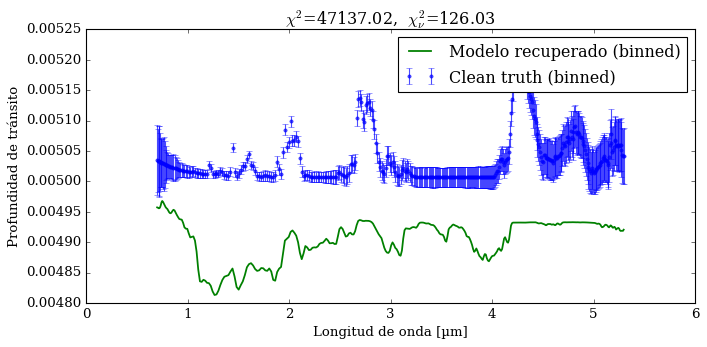

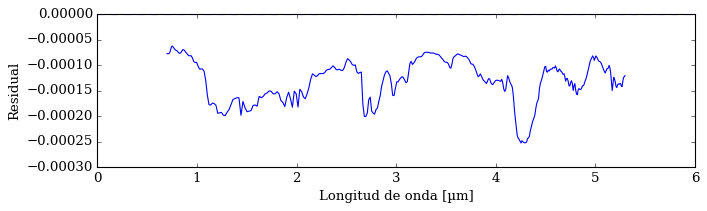

In [30]:
# --- Celda 6 (opcional): Guardar tabla y/o hacer un plot rápido ---
import matplotlib.pyplot as plt

# Guardar CSV con detalles
out_df = pd.DataFrame({
    "wl_um": wl_data,
    "half_bin_um": half_bin,
    "clean_binned": clean_binned,
    "model_binned": model_binned,
    "err_obs": err_obs,
    "residual": resid,
    "chi2_contrib": (resid/err_obs)**2
})
out_df.to_csv("chi2_vs_clean_table.csv", index=False)
print("Guardado: chi2_vs_clean_table.csv")

# Plot opcional (visual rápido)
plt.figure(figsize=(9,4.5))
plt.errorbar(wl_data, clean_binned, yerr=err_obs, fmt='.', alpha=0.7, label="Clean truth (binned)")
plt.plot(wl_data, model_binned, lw=1.6, label="Modelo recuperado (binned)")
plt.xlabel("Longitud de onda [µm]")
plt.ylabel("Profundidad de tránsito")
plt.title(rf"$\chi^2$={chi2:.2f},  $\chi^2_\nu$={chi2red:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,2.8))
plt.axhline(0, ls="--")
plt.plot(wl_data, resid, lw=1.0)
plt.xlabel("Longitud de onda [µm]")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()
